In [2]:
import os

!pip install -q kaggle==1.6.17

os.environ['KAGGLE_USERNAME'] = 'YOUR_KAGGLE_USERNAME'
os.environ['KAGGLE_KEY'] = 'YOUR_KAGGLE_KEY'

!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.7/82.7 kB 7.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:38<00:00, 15.4MB/s]
100% 2.29G/2.29G [02:38<00:00, 15.6MB/s]


In [3]:

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Dense, Flatten, Rescaling, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Conv2D, MaxPooling2D, Rescaling, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [5]:
os.listdir('chest_xray_data')

['chest_xray']

In [6]:
from PIL import Image
img = Image.open('chest_xray_data/chest_xray/test/NORMAL/IM-0001-0001.jpeg')          # Show Specific Image to get Size
img.size

(1857, 1317)

In [7]:
import tensorflow as tf


DATA_PATH = 'chest_xray_data/chest_xray/train'


train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,            # Path of the folder which contain training data
    labels='inferred',                # to make each class name as it is folder name
    label_mode='int',                 # to make classes encoded as (0,1,2,3......)
    color_mode='rgb',                 # this is because our images are 3 channels not Gray scale
    shuffle=True,                     # make the data Shuffled not AAAAA or BBBBB make it ACBFDS and so on
    seed=42,                          # like Random_state
    image_size=(64, 64),              # image size will be (64,64)
    batch_size=32,
    subset='training'                     # batch_size will be 32 image per iteration
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_PATH,
    validation_split=0.2,
    labels='inferred',
    label_mode='int',
    color_mode='rgb',
    shuffle=True,
    seed=42,
    image_size=(64, 64),
    batch_size=32,
    subset='validation'
)

# Performance optimization
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.


In [8]:
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model,Sequential

In [9]:
#### input layers
input_ = Input(shape=(64,64,3))
scale_input = Rescaling(1/255.0)(input_) # make (255.0) float to avoid datatype mismatch

#### convolutional layer 1 [best structer (conv-conv-maxpool) -> (conv-conv-maxpool) .... (dense) -> (output)]
hidden =Conv2D(64,kernel_size=3,padding='same',kernel_initializer="he_normal")(scale_input)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden) # activation function

hidden =Conv2D(64,kernel_size=3,padding='same',kernel_initializer="he_normal")(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = MaxPool2D()(hidden)
hidden = Dropout(0.25)(hidden) # Added Dropout

#### convolutional layer 2
hidden =Conv2D(128,kernel_size=3,padding='same',kernel_initializer="he_normal")(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden =Conv2D(128,kernel_size=3,padding='same',kernel_initializer="he_normal")(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = MaxPool2D()(hidden)
hidden = Dropout(0.25)(hidden) # Added Dropout

#### convolutional layer 2
hidden =Conv2D(256,kernel_size=3,padding='same',kernel_initializer="he_normal")(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden =Conv2D(256,kernel_size=3,padding='same',kernel_initializer="he_normal")(hidden)
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)

hidden = MaxPool2D()(hidden)
hidden = Dropout(0.25)(hidden) # Added Dropout

hidden = Flatten()(hidden)

#### dense layer
hidden = Dense(256, kernel_initializer="he_normal")(hidden) # Reduced dense layer units
hidden = BatchNormalization()(hidden)
hidden = ReLU()(hidden)
hidden = Dropout(0.5)(hidden) # Added Dropout before output

#### output layer
output = Dense(2,activation='softmax',kernel_initializer="glorot_normal")(hidden)

model = Model(inputs=input_,outputs=output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,345,090 (20.39 MB)

 Trainable params: 5,342,786 (20.38 MB)

 Non-trainable params: 2,304 (9.00 KB)

In [10]:
from tensorflow.keras.optimizers import Adam
optimizer = Adam(learning_rate=0.001)
model.compile(loss='sparse_categorical_crossentropy',optimizer=optimizer,metrics=['accuracy'])

In [11]:
history = model.fit(train_ds,validation_data=val_ds,epochs=20)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 62s 165ms/step - accuracy: 0.9264 - loss: 0.2199 - val_accuracy: 0.9089 - val_loss: 0.2320
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 37s 108ms/step - accuracy: 0.9638 - loss: 0.1017 - val_accuracy: 0.8169 - val_loss: 0.5621
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 37s 109ms/step - accuracy: 0.9710 - loss: 0.0868 - val_accuracy: 0.9434 - val_loss: 0.1595
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 38s 109ms/step - accuracy: 0.9739 - loss: 0.0730 - val_accuracy: 0.9693 - val_loss: 0.0764
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 74ms/step - accuracy: 0.9768 - loss: 0.0649 - val_accuracy: 0.9636 - val_loss: 0.1024
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 73ms/step - accuracy: 0.9780 - loss: 0.0544 - val_accuracy: 0.9779 - val_loss: 0.0756
Epoch 7/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 34s 81ms/step - accuracy: 0.9839 - loss: 0.0463 - val_accuracy: 0.9779 - val_loss: 0.0699
Epoch 8/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 32s 75ms/step - accuracy: 0.9839 - loss: 0.043

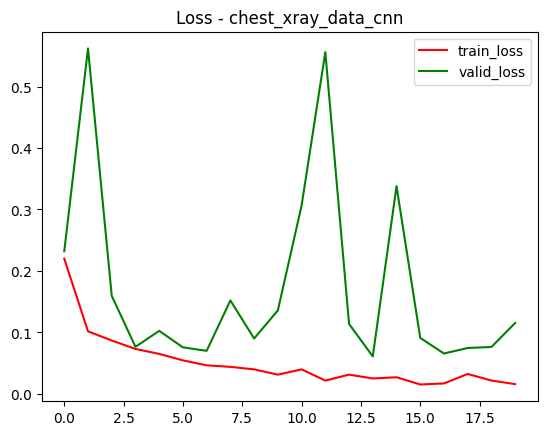

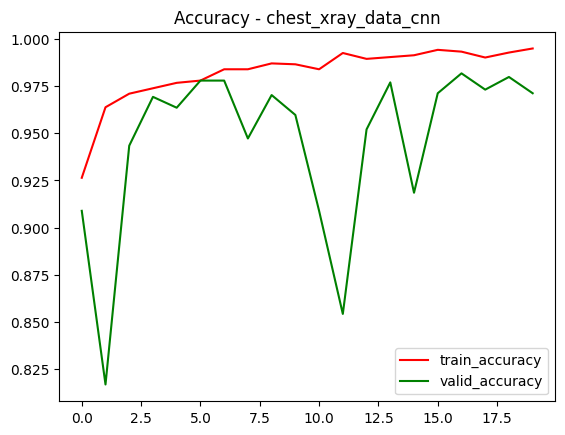

In [12]:
import matplotlib.pyplot as plt

def plot_loss_acc(history, model_name='cnn_model'):
    plt.title(f"Loss - {model_name}")
    plt.plot(history.history['loss'], c='red', label='train_loss')
    plt.plot(history.history['val_loss'], c='green', label='valid_loss')
    plt.legend()
    plt.show()

    plt.title(f"Accuracy - {model_name}")
    plt.plot(history.history['accuracy'], c='red', label='train_accuracy')
    plt.plot(history.history['val_accuracy'], c='green', label='valid_accuracy')
    plt.legend()
    plt.show()

plot_loss_acc(history, model_name='chest_xray_data_cnn')

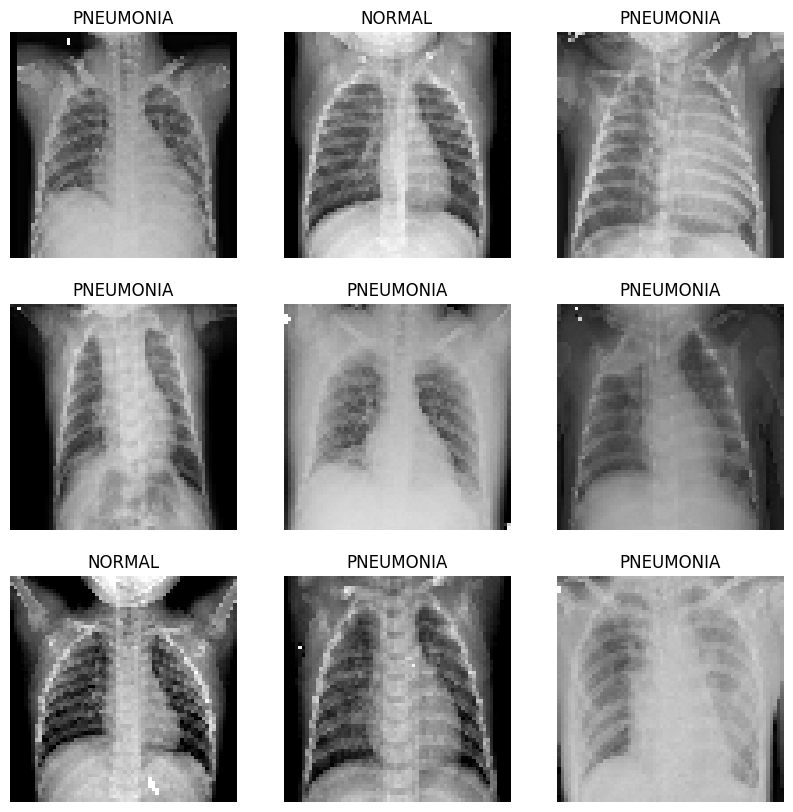

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        # Assuming your labels are 0 for 'NORMAL' and 1 for 'PNEUMONIA'
        if labels[i] == 0:
            plt.title("NORMAL")
        else:
            plt.title("PNEUMONIA")
        plt.axis("off")
plt.show()

## Confusion Matrix

Predictions re-calculated with a threshold of 0.7


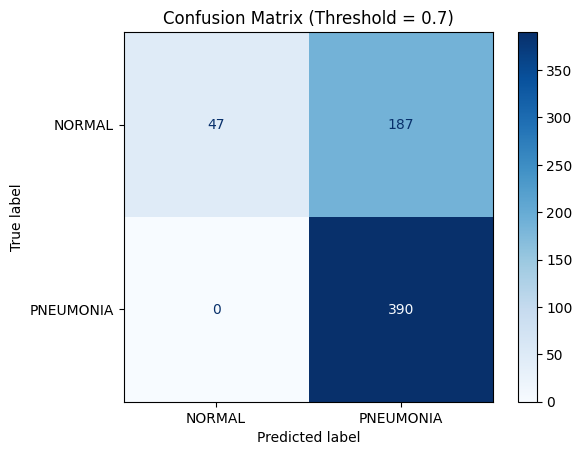

In [29]:

custom_threshold = 0.7


predicted_classes_tuned = (predictions[:, 1] >= custom_threshold).astype(int)

print(f"Predictions re-calculated with a threshold of {custom_threshold}")

cm_tuned = confusion_matrix(true_labels, predicted_classes_tuned)

disp_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=class_names)
disp_tuned.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix (Threshold = {custom_threshold})")
plt.show()
